# **Support Vector Machines (SVM)**
---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)

### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)

---

## Support Vector Machines (SVM)
Support Vector Machines (SVM) is a **supervised machine learning algorithm** used for both **classification and regression**, but it is mostly used for classification tasks.

## Key Idea
- Each data point is plotted in an **n-dimensional space** (n = number of features)  
- SVM finds the **optimal hyperplane** that best separates different classes  
- The goal is to **maximize the margin** (distance between hyperplane and nearest points)

## Important Concepts
- **Support Vectors** → data points closest to the hyperplane  
- **Margin** → distance between hyperplane and support vectors  
- **Hyperplane** → decision boundary  

## Equation (Linear SVM)
\[
$$w \cdot x + b = 0$$
\]

## Kernels (for non-linear data)
- Linear Kernel  
- Polynomial Kernel  
- Radial Basis Function (RBF) Kernel  

## Kernel Trick
- Allows SVM to handle **non-linear data**  
- Transforms data into higher dimensions without explicit computation  

## Key Points
- Works well in **high-dimensional spaces**  
- Effective when number of features > number of samples  
- Sensitive to choice of **kernel, C, and gamma**  

## Advantages
- Works well with clear margin of separation  
- Effective in high dimensions  
- Memory efficient (uses support vectors only)  

## Limitations
- Not suitable for very large datasets (slow training)  
- Sensitive to noise and overlapping classes  
- Choosing the right kernel can be tricky  

---

# SVC 

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix 
from sklearn.preprocessing import LabelEncoder

In [2]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [5]:
model = SVC(kernel='rbf')
# train  and predict the model
model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



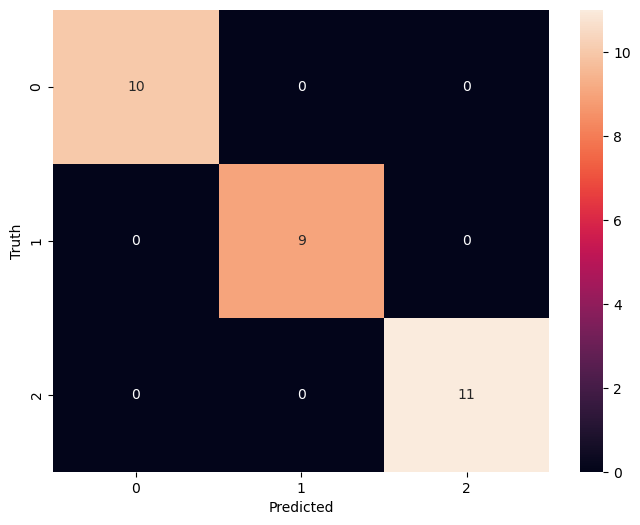

In [7]:
# draw the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# SVR

In [8]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
import numpy as np
import seaborn as sns
from sklearn.svm import SVR, SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [10]:
df = sns.load_dataset('diamonds')
df = df.sample(frac=0.2 , random_state=42)
X = df.drop('price', axis=1)
y = df['price']

In [12]:
# convert categorical labels into numerical 
label_encoders = {}
for col in X.select_dtypes(include="category").columns :
    le = LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoders[col] = le

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [14]:
svr_model = SVR()
svr_model.fit(X_train, y_train)

# Predict the prices on the test set
y_pred = svr_model.predict(X_test)

In [15]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'Mean Absolute Percentage Error: {mape}')
# RMSE
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 13396005.286456719
R2 Score: 0.1692975856528134
Mean Absolute Error: 1995.5978850983934
Mean Absolute Percentage Error: 0.64279249965329
Root Mean Squared Error: 3660.0553665835055
